In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    ROOT = CURRENT_DIR.parent
else:
    ROOT = CURRENT_DIR


DATA_PATH = ROOT / "data" / "predictive_maintenance.csv"
MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "outputs"


MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)


print("Project root:", ROOT)
print("Dataset path:", DATA_PATH)

Project root: d:\Deep Learning\Anomaly Detection
Dataset path: d:\Deep Learning\Anomaly Detection\data\predictive_maintenance.csv


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )


df = pd.read_csv(DATA_PATH)


print("Dataset shape:", df.shape)

df.head()

Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]


TARGET = "Machine failure"


df[FEATURES + [TARGET]].head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,298.1,308.6,1551,42.8,0,0
1,298.2,308.7,1408,46.3,3,0
2,298.1,308.5,1498,49.4,5,0
3,298.2,308.6,1433,39.5,7,0
4,298.2,308.7,1408,40.0,9,0


In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df[TARGET],
)


print("Training records:", len(train_df))
print("Test records:", len(test_df))


print("\nTraining failure distribution:")
print(
    train_df[TARGET].value_counts(normalize=True)
)


print("\nTest failure distribution:")
print(
    test_df[TARGET].value_counts(normalize=True)
)

Training records: 8000
Test records: 2000

Training failure distribution:
Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Test failure distribution:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [6]:
normal_train_df = train_df[
    train_df[TARGET] == 0
].copy()


print(
    "Normal training records:",
    len(normal_train_df)
)

Normal training records: 7729


In [7]:
scaler = StandardScaler()


X_train_normal = scaler.fit_transform(
    normal_train_df[FEATURES]
)


X_test = scaler.transform(
    test_df[FEATURES]
)


y_test = test_df[TARGET].to_numpy()


print("Training shape:", X_train_normal.shape)
print("Test shape:", X_test.shape)

Training shape: (7729, 5)
Test shape: (2000, 5)


In [8]:
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.034,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


iso_model.fit(
    X_train_normal
)


print("Isolation Forest training completed.")

Isolation Forest training completed.


In [9]:
raw_predictions = iso_model.predict(
    X_test
)


iso_predictions = np.where(
    raw_predictions == -1,
    1,
    0
)


iso_scores = -iso_model.decision_function(
    X_test
)


print(
    "Detected anomalies:",
    iso_predictions.sum()
)

Detected anomalies: 78


In [10]:
print(
    classification_report(
        y_test,
        iso_predictions,
        target_names=[
            "Normal",
            "Failure"
        ],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97      1932
     Failure       0.13      0.15      0.14        68

    accuracy                           0.94      2000
   macro avg       0.55      0.56      0.55      2000
weighted avg       0.94      0.94      0.94      2000



In [11]:
iso_precision = precision_score(
    y_test,
    iso_predictions,
    zero_division=0,
)


iso_recall = recall_score(
    y_test,
    iso_predictions,
    zero_division=0,
)


iso_f1 = f1_score(
    y_test,
    iso_predictions,
    zero_division=0,
)


iso_auc = roc_auc_score(
    y_test,
    iso_scores,
)


print(
    f"Precision : {iso_precision:.4f}"
)

print(
    f"Recall    : {iso_recall:.4f}"
)

print(
    f"F1 Score  : {iso_f1:.4f}"
)

print(
    f"ROC AUC   : {iso_auc:.4f}"
)

Precision : 0.1282
Recall    : 0.1471
F1 Score  : 0.1370
ROC AUC   : 0.8507


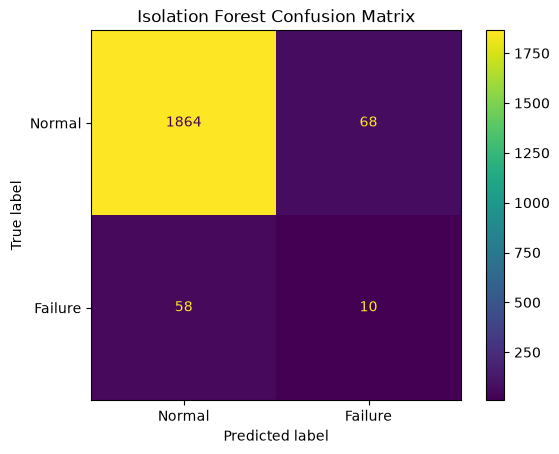

In [12]:
cm = confusion_matrix(
    y_test,
    iso_predictions
)


display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Failure"
    ]
)


display.plot()

plt.title(
    "Isolation Forest Confusion Matrix"
)

plt.show()

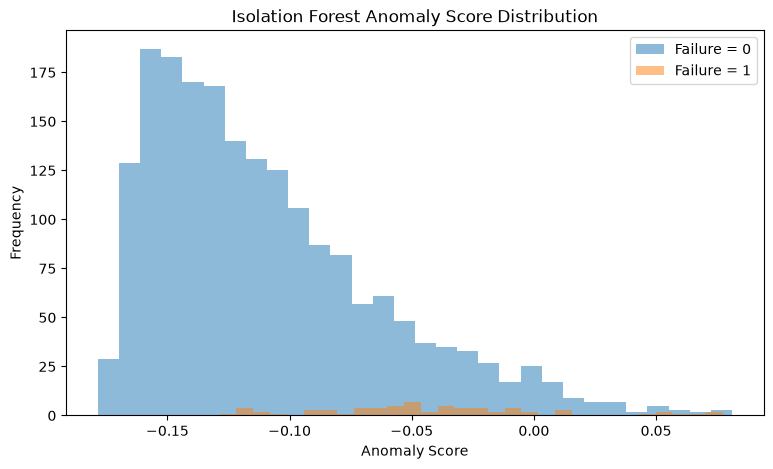

In [13]:
plt.figure(figsize=(9, 5))


for label in [0, 1]:

    subset_scores = iso_scores[
        y_test == label
    ]

    plt.hist(
        subset_scores,
        bins=30,
        alpha=0.5,
        label=f"Failure = {label}"
    )


plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.title(
    "Isolation Forest Anomaly Score Distribution"
)
plt.legend()
plt.show()

In [14]:
iso_results = test_df[
    [
        "UDI",
        "Product ID",
        TARGET
    ] + FEATURES
].copy()


iso_results[
    "iso_prediction"
] = iso_predictions


iso_results[
    "iso_anomaly_score"
] = iso_scores


iso_results.sort_values(
    "iso_anomaly_score",
    ascending=False,
).head(20)

,UDI,Product ID,Machine failure,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],iso_prediction,iso_anomaly_score
4899,4900,L52079,0,303.6,312.3,2168,17.7,219,1,0.081051
926,927,L48106,1,295.6,306.1,1372,55.6,215,1,0.077226
4296,4297,L51476,1,301.8,310.2,2825,5.8,215,1,0.076671
2421,2422,L49601,0,298.9,308.2,2384,15.0,19,1,0.073012
989,990,M15849,0,296.2,307.0,2119,18.3,159,1,0.072750
1089,1090,M15949,0,296.9,307.7,2008,17.5,3,1,0.068440
7086,7087,L54266,0,300.6,310.4,2514,13.4,215,1,0.068179
380,381,L47560,1,297.5,308.3,2564,12.8,127,1,0.065189
924,925,L48104,0,295.5,306.0,1800,27.6,208,1,0.062954
9038,9039,L56218,0,297.3,308.3,2358,14.9,49,1,0.062532


In [15]:
joblib.dump(
    scaler,
    MODEL_DIR / "scaler.pkl"
)


joblib.dump(
    iso_model,
    MODEL_DIR / "isolation_forest.pkl"
)


iso_results.to_csv(
    OUTPUT_DIR / "iso_test_predictions.csv",
    index=False,
)


print(
    "Isolation Forest artifacts saved successfully."
)

Isolation Forest artifacts saved successfully.
